# One-way ANOVA: Condition A vs Condition C (pixel AOI, CTA)
Eye-tracking metrics per image. Each metric is compared between the two conditions.

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## 1. Load and clean the data
Converts `12.3%`, `0.59s` to numbers and `N/A` to NaN (images with no fixations).

In [7]:
BASE = Path("../..")
FILE_A = BASE / "Condition A" / "box" / "headline.csv"
FILE_C = BASE / "Condition D" / "box" / "headline.csv"


def load(path):
    df = pd.read_csv(path, na_values=["N/A"])
    for col in df.columns.drop("Img"):
        if not pd.api.types.is_numeric_dtype(df[col]):
            df[col] = pd.to_numeric(df[col].astype(str).str.rstrip("%s"), errors="coerce")
    return df


a = load(FILE_A)
c = load(FILE_C)
metrics = [m for m in a.columns if m != "Img"]

print(f"Condition A: {len(a)} images | Condition C: {len(c)} images")
a.head()

Condition A: 20 images | Condition C: 20 images


,Img,VAI%,Avg. TTFF,Fix. Avg. Time Spent,Fixations,Avg. Fixation Duration,Avg. FFD,K-coefficient,Avg. Revisits
0,1,11.3,0.33,0.17,5,0.11,0.15,1.06,0.00
1,2,40.0,1.50,0.67,28,0.29,0.31,0.03,0.29
2,3,32.1,1.51,0.60,18,0.35,0.36,-0.15,0.29
3,4,11.7,0.35,0.09,5,0.09,0.09,-0.14,0.00
4,5,51.4,2.20,0.68,46,0.25,0.22,0.12,0.90


## 2. Run the ANOVA for every metric
NaN values are dropped per metric. Reports F, p, eta squared (effect size) and Levene's test for equal variances.

In [8]:
def one_way_anova(x, y):
    x, y = x.dropna(), y.dropna()
    f, p = stats.f_oneway(x, y)
    allv = np.concatenate([x, y])
    ss_between = len(x) * (x.mean() - allv.mean()) ** 2 + len(y) * (y.mean() - allv.mean()) ** 2
    ss_total = ((allv - allv.mean()) ** 2).sum()
    return {
        "n_A": len(x), "n_C": len(y),
        "mean_A": x.mean(), "sd_A": x.std(ddof=1),
        "mean_C": y.mean(), "sd_C": y.std(ddof=1),
        "F": f, "df": f"1, {len(x) + len(y) - 2}",
        "p": p, "eta_sq": ss_between / ss_total,
        "levene_p": stats.levene(x, y).pvalue,
    }


results = pd.DataFrame({m: one_way_anova(a[m], c[m]) for m in metrics}).T
results.index.name = "metric"
results = results.reset_index().infer_objects()
results["significant (p<.05)"] = results["p"].astype(float) < 0.05
results = results.round(4)
results

,metric,n_A,n_C,mean_A,sd_A,mean_C,sd_C,F,df,p,eta_sq,levene_p,significant (p<.05)
0,VAI%,20,19,35.7150,13.1255,50.8684,9.1013,17.3757,"1, 37",0.0002,0.3195,0.1653,True
1,Avg. TTFF,20,19,1.6585,0.7164,1.5195,0.5633,0.4506,"1, 37",0.5062,0.0120,0.2550,False
2,Fix. Avg. Time Spent,20,19,0.6385,0.2400,0.9395,0.4000,8.2166,"1, 37",0.0068,0.1817,0.2216,True
3,Fixations,20,19,29.0000,14.3674,67.6316,38.6627,17.4524,"1, 37",0.0002,0.3205,0.0761,True
4,Avg. Fixation Duration,20,19,0.2555,0.0736,0.2247,0.0299,2.8678,"1, 37",0.0988,0.0719,0.0251,False
5,Avg. FFD,20,19,0.2605,0.0735,0.2263,0.0322,3.4720,"1, 37",0.0704,0.0858,0.0131,False
6,K-coefficient,20,19,0.0615,0.3880,0.1874,0.2763,1.3487,"1, 37",0.2529,0.0352,0.4646,False
7,Avg. Revisits,20,19,0.4680,0.3007,1.0553,0.5889,15.6201,"1, 37",0.0003,0.2968,0.0132,True


## 3. Save results

In [9]:
results.to_csv("anova_A_vs_D_box_headline_results.csv", index=False)
print("Saved anova_A_vs_C_pixel_cta_results.csv")

Saved anova_A_vs_C_pixel_cta_results.csv


## 4. Visualize
Boxplots per metric, A vs C.

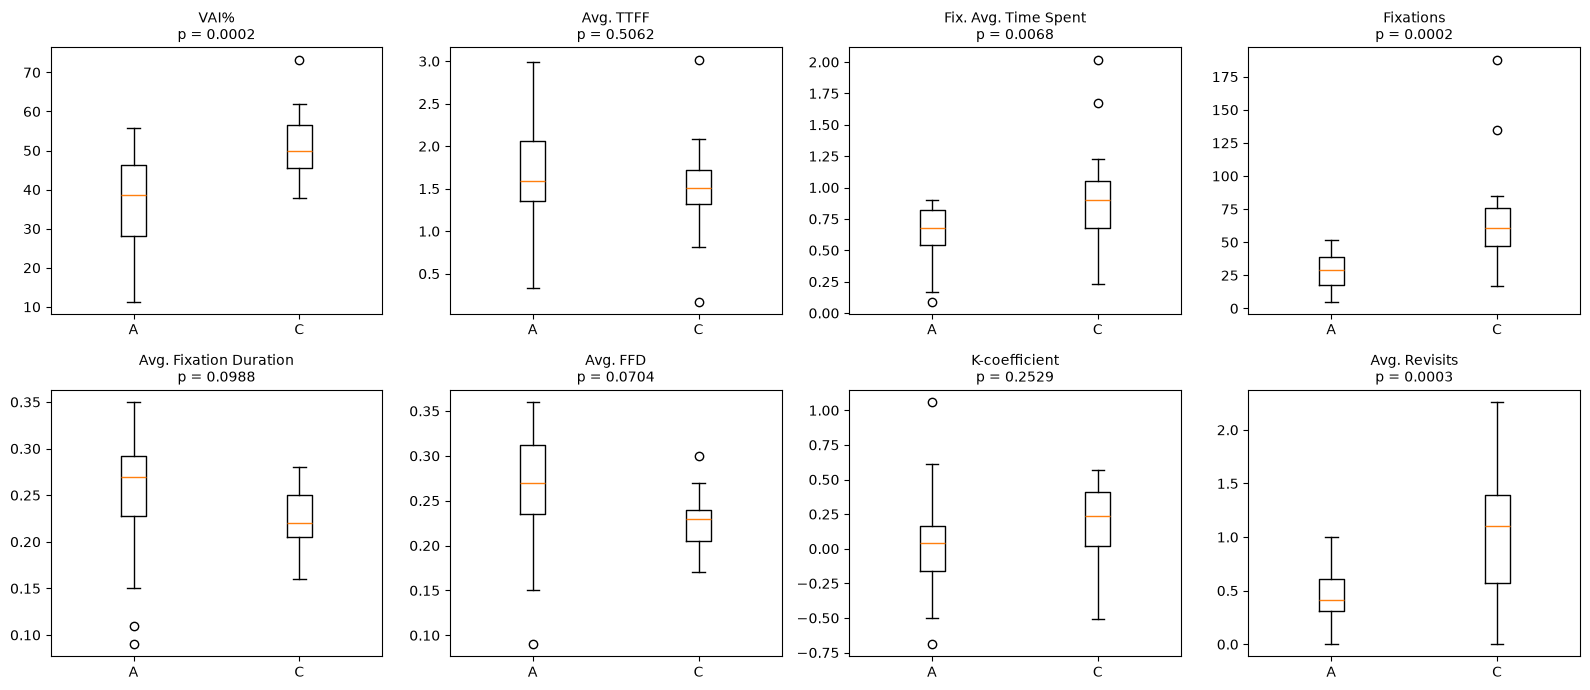

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, m in zip(axes.ravel(), metrics):
    ax.boxplot([a[m].dropna(), c[m].dropna()])
    ax.set_xticklabels(["A", "C"])
    p = results.loc[results["metric"] == m, "p"].iloc[0]
    ax.set_title(f"{m}\np = {p:.4f}", fontsize=10)
plt.tight_layout()
plt.show()